# Week 1 – Data Audit

## Objective

This notebook performs an initial audit of the patient metadata from the Parkinson's Disease Smartwatch (PADS) dataset.

The input file (`patients.csv`) is a direct tabular consolidation of the original `patients/*.json` files. No cleaning, preprocessing, or value transformations have been applied.

The objectives of this notebook are to:

- Inspect the dataset structure
- Review variable types
- Assess data completeness
- Examine participant distribution
- Summarize demographic characteristics
- Identify potential data quality issues before preprocessing

## 1. Import Libraries

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
# Load the dataset
patients_df = pd.read_csv("../data/interim/patients.csv")

## 3. Initial Dataset Inspection

In [21]:
# Preview the dataset
patients_df.head()

,patient_id,study_id,condition,label,disease_comment,age_at_diagnosis,age,height_cm,weight_kg,gender,handedness,appearance_in_kinship,appearance_in_first_grade_kinship,effect_of_alcohol_on_tremor,Target Class
0,1,PADS,Healthy,0,-,56,56,173,78,male,right,True,True,Unknown,Healthy
1,2,PADS,Other Movement Disorders,2,Left-Sided resting tremor and hypokinesia with...,69,81,193,104,male,right,False,NaN,No effect,Other Movement Disorders
2,3,PADS,Healthy,0,-,45,45,170,78,female,right,False,NaN,Unknown,Healthy
3,4,PADS,Parkinson's,1,IPS akinetic-rigid type,63,67,161,90,female,right,False,NaN,No effect,Parkinson's Disease
4,5,PADS,Parkinson's,1,IPS tremordominant type,65,75,172,86,male,left,False,NaN,Unknown,Parkinson's Disease


In [22]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Participants : {patients_df.shape[0]}")
print(f"Variables    : {patients_df.shape[1]}")

DATASET OVERVIEW
Participants : 469
Variables    : 15


### Interpretation

The dataset contains metadata for **469 participants** described by **14 original variables**. Each participant corresponds to a unique record from the PADS study, providing sufficient demographic and clinical information for the initial data audit.

## Dataset Structure

In [ ]:
# Display dataset information
patients_df.info()

In [6]:
audit_summary = pd.DataFrame({
    "Variable": patients_df.columns,
    "Data Type": patients_df.dtypes.values,
    "Missing Values": patients_df.isnull().sum().values,
    "Missing (%)": (
        patients_df.isnull().mean() * 100
    ).round(2).values,
    "Unique Values": patients_df.nunique().values
})

audit_summary

,Variable,Data Type,Missing Values,Missing (%),Unique Values
0,patient_id,int64,0,0.00,469
1,study_id,str,0,0.00,1
2,condition,str,0,0.00,6
3,label,int64,0,0.00,3
4,disease_comment,str,0,0.00,140
5,age_at_diagnosis,int64,0,0.00,65
6,age,int64,0,0.00,48
7,height_cm,int64,0,0.00,49
8,weight_kg,int64,0,0.00,77
9,gender,str,0,0.00,2


In [9]:
duplicate_ids = patients_df["patient_id"].duplicated().sum()

print(f"Duplicate participant IDs: {duplicate_ids}")

Duplicate participant IDs: 0


In [10]:
missing = patients_df.isnull().sum().sort_values(ascending=False)

missing

appearance_in_first_grade_kinship    288
patient_id                             0
condition                              0
label                                  0
disease_comment                        0
study_id                               0
age_at_diagnosis                       0
age                                    0
weight_kg                              0
height_cm                              0
gender                                 0
handedness                             0
appearance_in_kinship                  0
effect_of_alcohol_on_tremor            0
dtype: int64

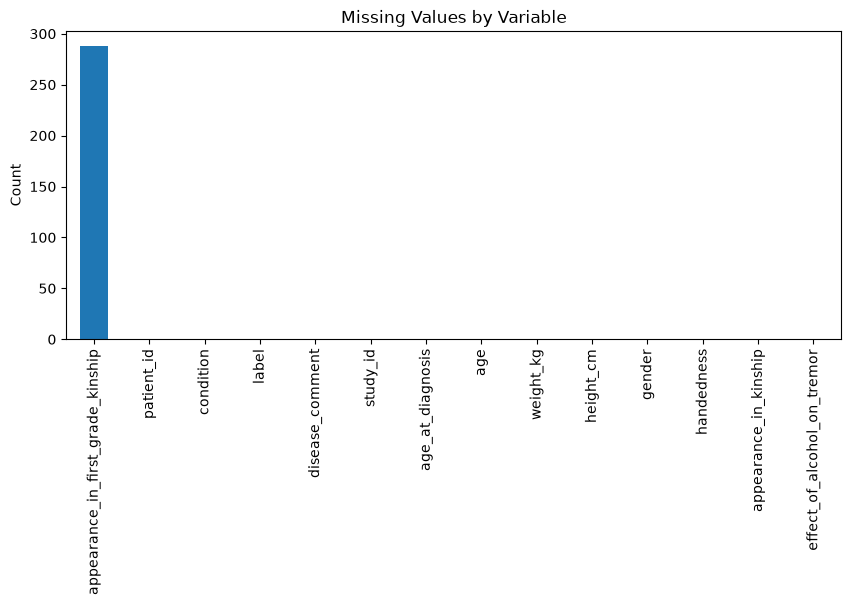

In [11]:
missing.plot.bar(figsize=(10,4))
plt.title("Missing Values by Variable")
plt.ylabel("Count")
plt.show()

### Data Quality Assessment

Overall, the dataset exhibits high data quality. No duplicate participant identifiers were detected, and most variables contain complete information. The only variable with a substantial proportion of missing values is `appearance_in_first_grade_kinship` (61.41%), which should be evaluated during preprocessing before deciding whether to retain or exclude it.

In [12]:
patients_df.describe(include="all")

,patient_id,study_id,condition,label,disease_comment,age_at_diagnosis,age,height_cm,weight_kg,gender,handedness,appearance_in_kinship,appearance_in_first_grade_kinship,effect_of_alcohol_on_tremor
count,469.000000,469,469,469.000000,469,469.000000,469.000000,469.000000,469.000000,469,469,469,181,469
unique,NaN,1,6,NaN,140,NaN,NaN,NaN,NaN,2,2,2,2,4
top,NaN,PADS,Parkinson's,NaN,-,NaN,NaN,NaN,NaN,male,right,False,False,Unknown
freq,NaN,469,276,NaN,94,NaN,NaN,NaN,NaN,281,437,343,91,228
mean,235.000000,NaN,NaN,1.074627,NaN,55.275053,64.240938,174.181237,81.899787,NaN,NaN,NaN,NaN,NaN
std,135.532899,NaN,NaN,0.637818,NaN,17.105225,10.698847,10.921397,17.916252,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,0.000000,NaN,0.000000,40.000000,55.000000,45.000000,NaN,NaN,NaN,NaN,NaN
25%,118.000000,NaN,NaN,1.000000,NaN,48.000000,56.000000,168.000000,69.000000,NaN,NaN,NaN,NaN,NaN
50%,235.000000,NaN,NaN,1.000000,NaN,58.000000,65.000000,175.000000,81.000000,NaN,NaN,NaN,NaN,NaN
75%,352.000000,NaN,NaN,1.000000,NaN,67.000000,72.000000,181.000000,92.000000,NaN,NaN,NaN,NaN,NaN


In [13]:
# Create target classes 
patients_df["Target Class"] = patients_df["condition"].replace({
    "Parkinson's": "Parkinson's Disease",
    "Essential Tremor": "Other Movement Disorders",
    "Atypical Parkinsonism": "Other Movement Disorders",
    "Multiple Sclerosis": "Other Movement Disorders"
})

# Generate participant count table
participant_counts = (
    patients_df["Target Class"]
    .value_counts()
    .rename_axis("Target Class")
    .reset_index(name="Participant Count")
)

# Calculate percentage distribution
participant_counts["Percentage (%)"] = (
    participant_counts["Participant Count"]
    / participant_counts["Participant Count"].sum()
    * 100
).round(2)

# Display participant count summary
print(f"Total Participants : {len(patients_df)}")
print(f"Total Features     : {patients_df.shape[1]}")
print(f"Target Classes     : {participant_counts.shape[0]}")

# Display participant count table
participant_counts

Total Participants : 469
Total Features     : 15
Target Classes     : 3


,Target Class,Participant Count,Percentage (%)
0,Parkinson's Disease,276,58.85
1,Other Movement Disorders,114,24.31
2,Healthy,79,16.84


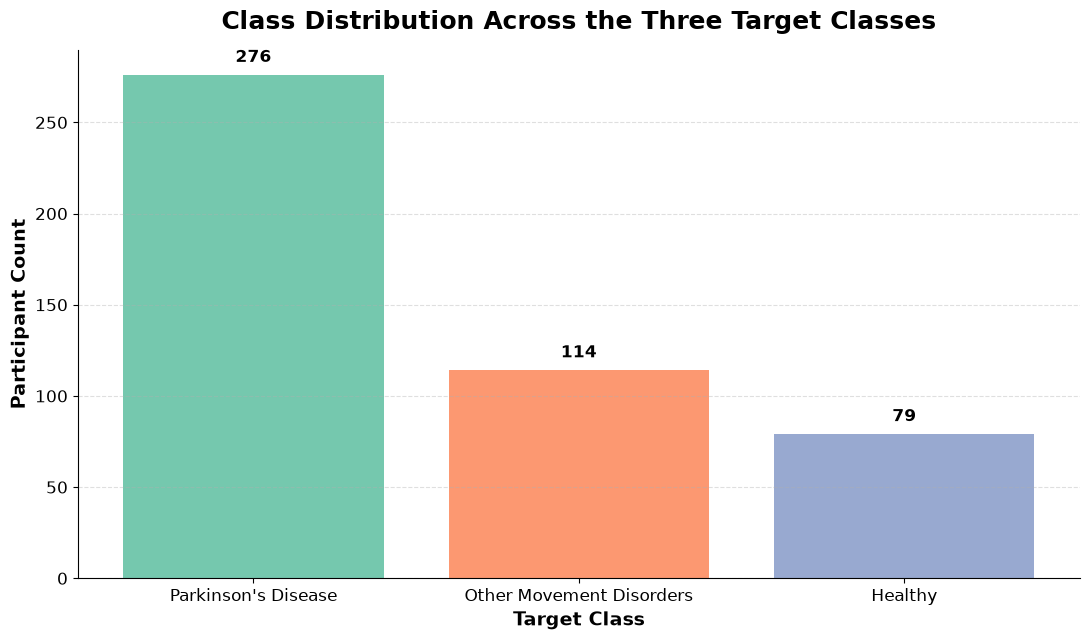

In [14]:
# Create class distribution bar chart
plt.figure(figsize=(11, 6.5))

# Set bar colors
colors = plt.cm.Set2.colors

# Create bar chart
bars = plt.bar(
    participant_counts["Target Class"],
    participant_counts["Participant Count"],
    color=colors,
    alpha=0.9
)

# Add participant count labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Chart title
plt.title(
    "Class Distribution Across the Three Target Classes",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Target Class",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Participant Count",
    fontsize=14,
    fontweight="bold"
)

# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

### Target Class Distribution

To simplify the classification problem, the original diagnostic categories were consolidated into three clinically meaningful target classes: Healthy, Parkinson's Disease, and Other Movement Disorders. Parkinson's disease represents the majority class (58.85%), indicating a moderate class imbalance that should be considered during model development and evaluation.

In [15]:
# Generate OMD subtype table
omd_subtypes = (
    patients_df[patients_df["Target Class"] == "Other Movement Disorders"]["condition"]
    .value_counts()
    .rename_axis("OMD Subtype")
    .reset_index(name="Participant Count")
)

# Calculate percentage distribution within the OMD class
omd_subtypes["Percentage (%)"] = (
    omd_subtypes["Participant Count"]
    / omd_subtypes["Participant Count"].sum()
    * 100
).round(2)

# Display OMD subtype table
omd_subtypes

,OMD Subtype,Participant Count,Percentage (%)
0,Other Movement Disorders,60,52.63
1,Essential Tremor,28,24.56
2,Atypical Parkinsonism,15,13.16
3,Multiple Sclerosis,11,9.65


### Other Movement Disorders Composition

The Other Movement Disorders class is composed of several neurological conditions, with the largest subgroup corresponding to generic movement disorders (52.63%), followed by Essential Tremor (24.56%), Atypical Parkinsonism (13.16%), and Multiple Sclerosis (9.65%). The heterogeneity of this class may increase the difficulty of distinguishing Parkinson's disease from other movement disorders.

In [16]:
patients_df.columns

Index(['patient_id', 'study_id', 'condition', 'label', 'disease_comment',
       'age_at_diagnosis', 'age', 'height_cm', 'weight_kg', 'gender',
       'handedness', 'appearance_in_kinship',
       'appearance_in_first_grade_kinship', 'effect_of_alcohol_on_tremor',
       'Target Class'],
      dtype='str')

In [17]:
pd.crosstab(patients_df["condition"], patients_df["label"])

label,0,1,2
condition,,,
Atypical Parkinsonism,0,0,15
Essential Tremor,0,0,28
Healthy,79,0,0
Multiple Sclerosis,0,0,11
Other Movement Disorders,0,0,60
Parkinson's,0,276,0


## Demographic Exploration

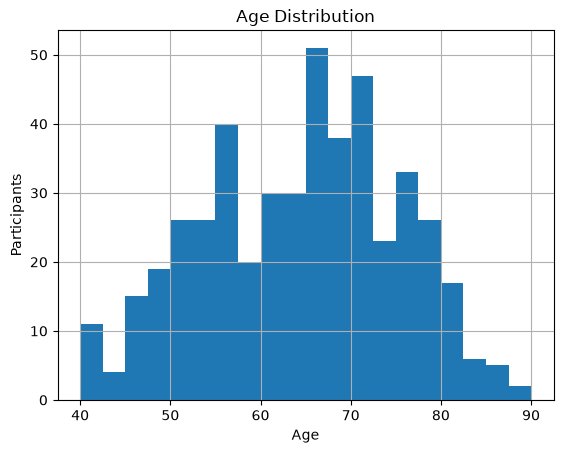

In [18]:
patients_df["age"].hist(bins=20)

plt.xlabel("Age")
plt.ylabel("Participants")
plt.title("Age Distribution")
plt.show()

### Age Distribution

Participant ages range from **40 to 90 years**, with a mean age of **64.2 years** and a median of **65 years**. The distribution is concentrated between approximately **55 and 75 years**, which is consistent with the typical age profile of Parkinson's disease and other movement disorders. No implausible age values or obvious outliers were observed.

In [19]:
#gender
patients_df["gender"].value_counts()

gender
male      281
female    188
Name: count, dtype: int64

### Gender Distribution

The dataset contains **281 male participants (59.9%)** and **188 female participants (40.1%)**. This moderate predominance of male participants is consistent with the higher prevalence of Parkinson's disease reported in epidemiological studies.

In [20]:
patients_df["handedness"].value_counts()

handedness
right    437
left      32
Name: count, dtype: int64

### Handedness

Most participants are **right-handed (437 individuals; 93.2%)**, while only a small proportion are left-handed. This distribution closely resembles that of the general population and is unlikely to introduce systematic bias.

# Conclusion

The Week 1 data audit confirmed that the patient metadata is complete, internally consistent, and suitable for further analysis. The dataset contains no duplicate participants, minimal missing data aside from one family history variable, and clinically plausible demographic characteristics. After consolidating the original diagnoses into three target classes, the dataset is ready for preprocessing, feature engineering, and the integration of questionnaire and movement data in the next stage of the project.